## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### List Dataset Contents

In [4]:
import os

print(os.listdir("/content/drive/MyDrive/carla_dataset"))

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip']


### Extract Dataset Archives

In [5]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/carla_dataset/train.zip', 'r') as zip_ref:
    zip_ref.extractall('train')

with zipfile.ZipFile('/content/drive/MyDrive/carla_dataset/validation.zip', 'r') as zip_ref:
    zip_ref.extractall('validation')

with zipfile.ZipFile('/content/drive/MyDrive/carla_dataset/test.zip', 'r') as zip_ref:
    zip_ref.extractall('test')

print("Dataset extracted successfully!")

Dataset extracted successfully!


### Import Libraries

In [6]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


### Load and Inspect Label DataFrames

In [7]:
labels_df_train = pd.read_csv("train/train/labels.csv")
labels_df_val = pd.read_csv("validation/validation/labels.csv")
labels_df_test = pd.read_csv("test/test/labels.csv")

print(labels_df_train.shape)
labels_df_train.head()

(7200, 7)


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


### Define Image Transformations

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Transform created!")

Transform created!


### Define DrivingDataset Class

In [9]:
class DrivingDataset(Dataset):
    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_folder = image_folder
        self.labels_df = labels_df
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        frame = self.labels_df.iloc[idx]["frame"]

        image_path = f"{self.image_folder}/{frame:06d}.jpg"

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = int(self.labels_df.iloc[idx][self.target_column])

        return image, torch.tensor(label)

### Create Traffic Light Training Dataset

In [10]:
traffic_light_dataset = DrivingDataset(
    image_folder="train/train/rgb-front",
    labels_df=labels_df_train,
    target_column="has_traffic_light",
    transform=transform
)

print("Training samples:", len(traffic_light_dataset))

Training samples: 7200


### Inspect Traffic Light Dataset Sample

In [11]:
image, label = traffic_light_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: tensor(0)


### Create Traffic Light Test Dataset

In [12]:
test_dataset = DrivingDataset(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_traffic_light",
    transform=transform
)

print("Test samples:", len(test_dataset))

Test samples: 3600


### Create Traffic Light Test DataLoader

In [13]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Number of batches:", len(test_loader))

Number of batches: 113


### Define Device (CPU/GPU)

In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


### Define Traffic Light Classifier Model

In [15]:
class TrafficLightClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

### Instantiate and Print Traffic Light Model

In [16]:
model = TrafficLightClassifier().to(device)

print(model)

TrafficLightClassifier(
  (model): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=50176, out_features=128, bias=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)


### List .pth Files in MyDrive

In [17]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

### Re-instantiate Traffic Light Model

In [18]:
model = TrafficLightClassifier().to(device)

### Define Loss Function and Optimizer for Traffic Light Model

In [19]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer created")

Loss and optimizer created


### Create Traffic Light Training DataLoader

In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    traffic_light_dataset,
    batch_size=32,
    shuffle=True
)

print("Number of training batches:", len(train_loader))

Number of training batches: 225


### Create Traffic Light Validation Dataset and DataLoader

In [21]:
val_dataset = DrivingDataset(
    image_folder="validation/validation/rgb-front",
    labels_df=labels_df_val,
    target_column="has_traffic_light",
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Validation samples:", len(val_dataset))

Validation samples: 3600


### Train Traffic Light Model

In [22]:
num_epochs = 3

losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 0.3600
Epoch 2/3, Loss: 0.1563
Epoch 3/3, Loss: 0.0980


### Plot Traffic Light Model Training Loss

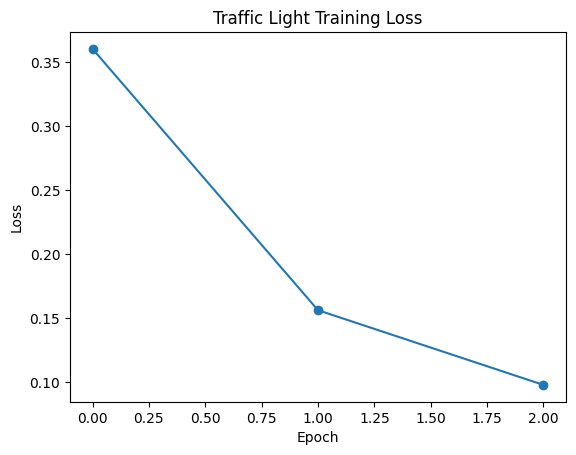

In [23]:
import matplotlib.pyplot as plt

plt.plot(losses, marker='o')
plt.title("Traffic Light Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Import Evaluation Metrics

In [24]:

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

### Evaluate Traffic Light Model

In [25]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.extend(preds.flatten())

        all_labels.extend(labels.numpy())

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Precision: 0.9315532154945468
Recall: 0.9585913312693498
F1-score: 0.9448788861338928


### Plot Traffic Light Model Confusion Matrix

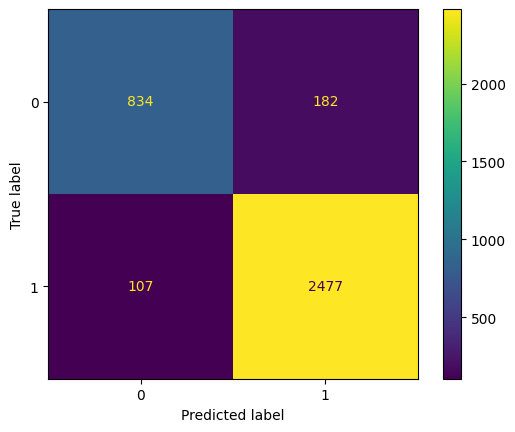

In [26]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()


### Create Pedestrian Datasets

In [27]:
pedestrian_train_dataset = DrivingDataset(
    image_folder="train/train/rgb-front",
    labels_df=labels_df_train,
    target_column="has_pedestrian",
    transform=transform
)

pedestrian_val_dataset = DrivingDataset(
    image_folder="validation/validation/rgb-front",
    labels_df=labels_df_val,
    target_column="has_pedestrian",
    transform=transform
)

pedestrian_test_dataset = DrivingDataset(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_pedestrian",
    transform=transform
)

print(len(pedestrian_train_dataset))
print(len(pedestrian_val_dataset))
print(len(pedestrian_test_dataset))


7200
3600
3600


### Create Pedestrian DataLoaders

In [28]:
pedestrian_train_loader = DataLoader(
    pedestrian_train_dataset,
    batch_size=32,
    shuffle=True
)

pedestrian_val_loader = DataLoader(
    pedestrian_val_dataset,
    batch_size=32,
    shuffle=False
)

pedestrian_test_loader = DataLoader(
    pedestrian_test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(pedestrian_train_loader))

225


### Instantiate Pedestrian Model, Loss, and Optimizer

In [29]:
pedestrian_model = TrafficLightClassifier().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    pedestrian_model.parameters(),
    lr=0.001
)

print("Pedestrian model created")

Pedestrian model created


### Train Pedestrian Model

In [30]:
num_epochs = 3

losses = []

for epoch in range(num_epochs):

    pedestrian_model.train()

    running_loss = 0

    for images, labels in pedestrian_train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = pedestrian_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(pedestrian_train_loader)

    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 0.5405
Epoch 2/3, Loss: 0.5086
Epoch 3/3, Loss: 0.4790


### Plot Pedestrian Model Training Loss

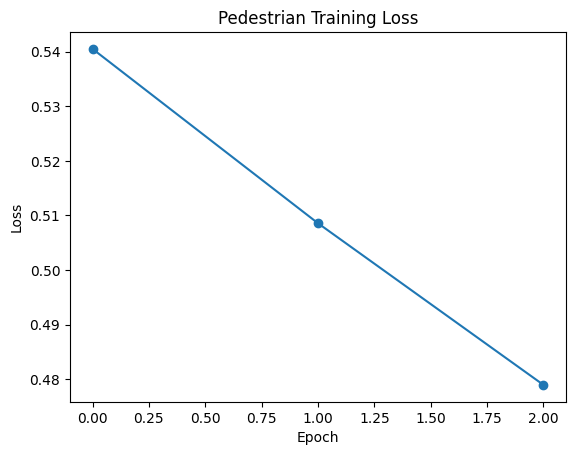

In [31]:
plt.plot(losses, marker='o')
plt.title("Pedestrian Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


### Evaluate Pedestrian Model

In [32]:

pedestrian_model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in pedestrian_test_loader:

        images = images.to(device)

        outputs = pedestrian_model(images)

        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.extend(preds.flatten())

        all_labels.extend(labels.numpy())

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.2111801242236025
Recall: 0.04815864022662889
F1-score: 0.0784313725490196


### Plot Pedestrian Model Confusion Matrix

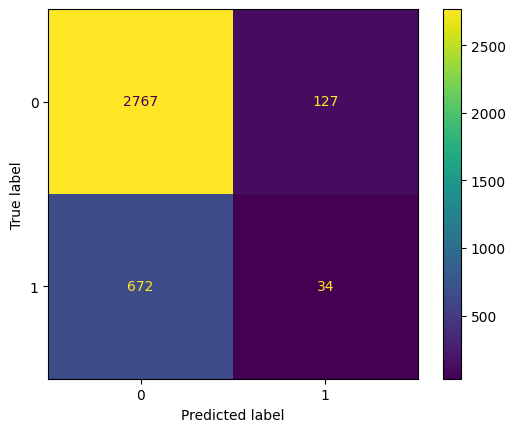

In [33]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

### Create Vehicle Datasets and DataLoaders

In [34]:
vehicle_train_dataset = DrivingDataset(
    image_folder="train/train/rgb-front",
    labels_df=labels_df_train,
    target_column="has_vehicle",
    transform=transform
)

vehicle_val_dataset = DrivingDataset(
    image_folder="validation/validation/rgb-front",
    labels_df=labels_df_val,
    target_column="has_vehicle",
    transform=transform
)

vehicle_test_dataset = DrivingDataset(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_vehicle",
    transform=transform
)

vehicle_train_loader = DataLoader(
    vehicle_train_dataset,
    batch_size=32,
    shuffle=True
)

vehicle_val_loader = DataLoader(
    vehicle_val_dataset,
    batch_size=32,
    shuffle=False
)

vehicle_test_loader = DataLoader(
    vehicle_test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(vehicle_train_dataset))
print(len(vehicle_val_dataset))
print(len(vehicle_test_dataset))

7200
3600
3600


### Instantiate Vehicle Model, Loss, and Optimizer

In [35]:

vehicle_model = TrafficLightClassifier().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    vehicle_model.parameters(),
    lr=0.001
)

print("Vehicle model created")

Vehicle model created


### Train Vehicle Model

In [36]:
num_epochs = 3

losses = []

for epoch in range(num_epochs):

    vehicle_model.train()

    running_loss = 0

    for images, labels in vehicle_train_loader:

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = vehicle_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(vehicle_train_loader)

    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 0.5035
Epoch 2/3, Loss: 0.4014
Epoch 3/3, Loss: 0.3576


### Plot Vehicle Model Training Loss

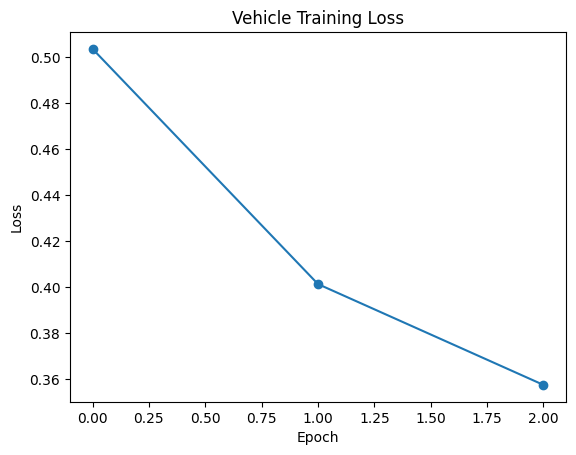

In [37]:
import matplotlib.pyplot as plt

plt.plot(losses, marker='o')
plt.title("Vehicle Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Evaluate Vehicle Model

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

vehicle_model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in vehicle_test_loader:

        images = images.to(device)

        outputs = vehicle_model(images)

        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()

        all_preds.extend(preds.flatten())

        all_labels.extend(labels.numpy())

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8815238095238095
Recall: 0.857037037037037
F1-score: 0.8691079812206572


### Plot Vehicle Model Confusion Matrix

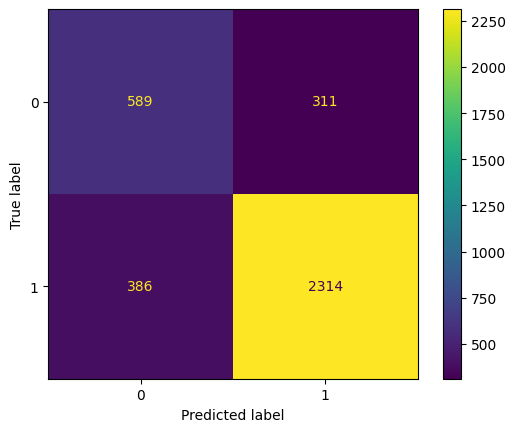

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

### Save Traffic Light Model

In [41]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"
)

print("Traffic Light model saved")

Traffic Light model saved


### Save Pedestrian Model

In [42]:

torch.save(
    pedestrian_model.state_dict(),
    "/content/drive/MyDrive/carla_dataset/pedestrian_model.pth"
)

print("Pedestrian model saved")

Pedestrian model saved


### Save Vehicle Model

In [43]:

torch.save(
    vehicle_model.state_dict(),
    "/content/drive/MyDrive/carla_dataset/vehicle_model.pth"
)

print("Vehicle model saved")

Vehicle model saved


### Verify Saved Model Files

In [44]:

import os

for root, dirs, files in os.walk("/content/drive/MyDrive/carla_dataset"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

/content/drive/MyDrive/carla_dataset/traffic_light_model.pth
/content/drive/MyDrive/carla_dataset/pedestrian_model.pth
/content/drive/MyDrive/carla_dataset/vehicle_model.pth
